# **1. Import Libraries**

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [40]:
from nltk.corpus import stopwords
from collections import Counter
import nltk
import re

nltk.download('stopwords')
arabic_stopwords = set(stopwords.words('arabic'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **2. Load Dataset**

In [3]:
dataset_path = "/content/classfiy_data.json"

In [10]:
dataset = pd.read_json(dataset_path)

texts = dataset["question"]

labels_1 = dataset["classification"]
labels_2 = dataset["intent"]

In [12]:
dataset.head()

,index,question,classification,intent
0,0,أبحث عن هاتف سامسونج.,simple,search_product
1,1,عرض لي لابتوبات الألعاب.,simple,search_product
2,2,أريد تيشيرتات رجالية.,simple,search_product
3,3,ابغى أجهزة منزلية.,simple,search_product
4,4,دوري على اكسسوارات موبايل.,simple,search_product


# **3. EDA**

In [17]:
print(f"Number of samples: {len(texts)}")
print(f"Number of complexity classes: {len(set(labels_1))}")
print(f"Classes: {set(labels_1)}")

print(f"Number of intent classes: {len(set(labels_2))}")
print(f"Classes: {set(labels_2)}")

Number of samples: 8000
Number of complexity classes: 2
Classes: {'complex', 'simple'}
Number of intent classes: 10
Classes: {'product_availability', 'ask_about_order', 'ask_return', 'ask_warranty', 'ask_shipping', 'ask_price', 'product_specifications', 'others', 'search_product', 'compare_products'}


In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   index            8000 non-null   int64 
 1   question         8000 non-null   object
 2   classification   8000 non-null   object
 3   intent           8000 non-null   object
 4   sentence_length  8000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 312.6+ KB


In [20]:
print(f"Number of null samples: {dataset.isna().sum().sum()}")
print(f"Number of duplicate samples: {len(dataset[dataset.duplicated()])}")

Number of null samples: 0
Number of duplicate samples: 0


In [25]:
def get_class_distribution(labels):
    counts = labels.value_counts().reset_index()
    counts.columns = ["Class", "Count"]
    counts["Percentage"] = (counts["Count"] / counts["Count"].sum()) * 100
    return counts


classification_counts = get_class_distribution(dataset["classification"])
print(classification_counts)

intent_counts = get_class_distribution(dataset["intent"])
print(intent_counts)

     Class  Count  Percentage
0  complex   4272        53.4
1   simple   3728        46.6
                    Class  Count  Percentage
0          search_product    860     10.7500
1        compare_products    828     10.3500
2  product_specifications    823     10.2875
3               ask_price    814     10.1750
4            ask_warranty    806     10.0750
5    product_availability    806     10.0750
6         ask_about_order    801     10.0125
7              ask_return    792      9.9000
8            ask_shipping    764      9.5500
9                  others    706      8.8250


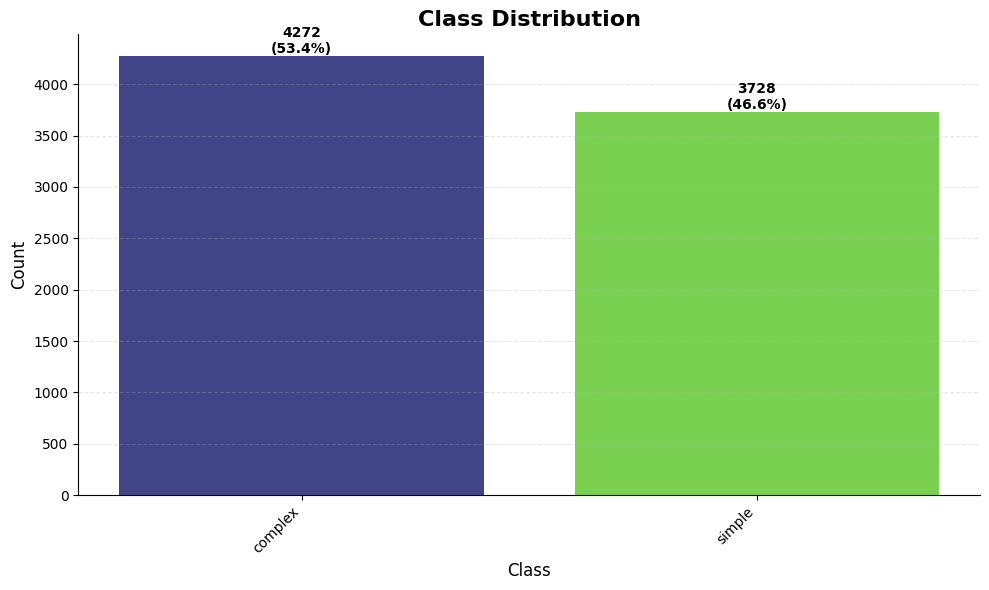

In [31]:

def plot_class_distribution(labels):
    counts = get_class_distribution(labels)

    fig, ax = plt.subplots(figsize=(10, 6))

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(counts)))

    bars = ax.bar(counts["Class"], counts["Count"], color=colors)

    ax.set_title("Class Distribution", fontsize=16, fontweight='bold')
    ax.set_xlabel("Class", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)

    plt.xticks(rotation=45, ha='right')

    for i, bar in enumerate(bars):
        height = bar.get_height()
        percentage = counts["Percentage"][i]
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}\n({percentage:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_class_distribution(dataset["classification"])

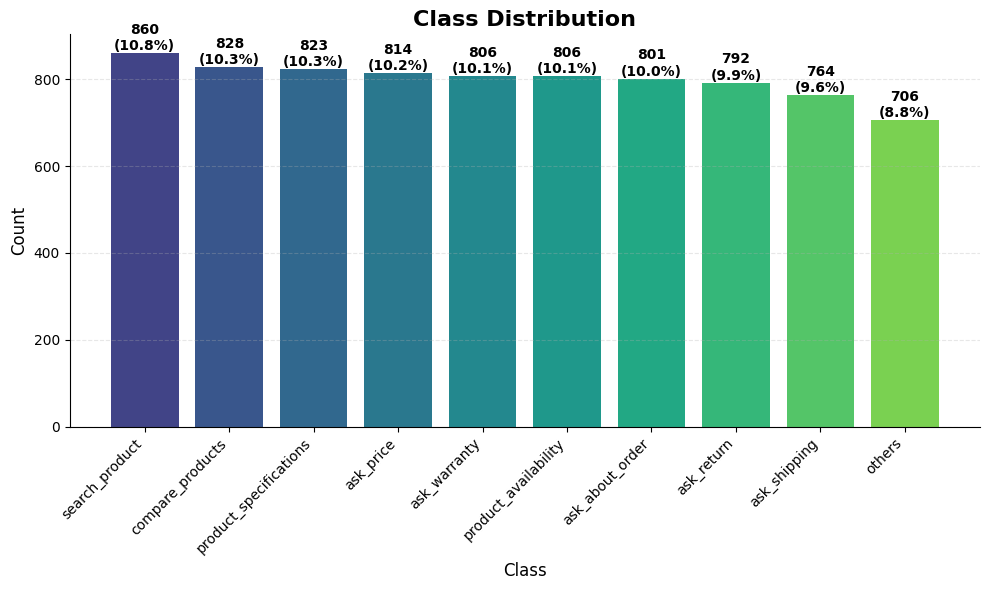

In [32]:
plot_class_distribution(dataset["intent"])

In [33]:
def get_sentence_length(sentence):
  return len(sentence.split())

dataset["sentence_length"] = dataset["question"].apply(get_sentence_length)
dataset.head(10)

,index,question,classification,intent,sentence_length
0,0,أبحث عن هاتف سامسونج.,simple,search_product,4
1,1,عرض لي لابتوبات الألعاب.,simple,search_product,4
2,2,أريد تيشيرتات رجالية.,simple,search_product,3
3,3,ابغى أجهزة منزلية.,simple,search_product,3
4,4,دوري على اكسسوارات موبايل.,simple,search_product,4
5,5,فين ألاقي أحذية رياضية ماركة نايكي؟,simple,search_product,6
6,6,أريد البحث عن سماعات بلوتوث.,simple,search_product,5
7,7,هل لديكم ألعاب بلاي ستيشن 5؟,simple,search_product,6
8,8,أبحث عن غسالة ملابس.,simple,search_product,4
9,9,اعرض لي ساعات ذكية.,simple,search_product,4


In [37]:
def count_arabic_stopwords(text):
    if not isinstance(text, str):
        return 0
    words = text.split()
    count = sum(1 for word in words if word in arabic_stopwords)
    return count

dataset['num_arabic_stopwords'] = dataset['question'].apply(count_arabic_stopwords)
dataset.head(10)

,index,question,classification,intent,sentence_length,num_arabic_stopwords
0,0,أبحث عن هاتف سامسونج.,simple,search_product,4,1
1,1,عرض لي لابتوبات الألعاب.,simple,search_product,4,1
2,2,أريد تيشيرتات رجالية.,simple,search_product,3,0
3,3,ابغى أجهزة منزلية.,simple,search_product,3,0
4,4,دوري على اكسسوارات موبايل.,simple,search_product,4,1
5,5,فين ألاقي أحذية رياضية ماركة نايكي؟,simple,search_product,6,0
6,6,أريد البحث عن سماعات بلوتوث.,simple,search_product,5,1
7,7,هل لديكم ألعاب بلاي ستيشن 5؟,simple,search_product,6,1
8,8,أبحث عن غسالة ملابس.,simple,search_product,4,1
9,9,اعرض لي ساعات ذكية.,simple,search_product,4,1


In [39]:
def repeated_words(text):
    if not isinstance(text, str):
        return {}
    words = text.split()
    word_counts = Counter(words)
    repeated = {word: count for word, count in word_counts.items() if count > 1}
    return repeated

dataset['repeated_words'] = dataset['question'].apply(repeated_words)

dataset.head(10)

,index,question,classification,intent,sentence_length,num_arabic_stopwords,repeated_words
0,0,أبحث عن هاتف سامسونج.,simple,search_product,4,1,{}
1,1,عرض لي لابتوبات الألعاب.,simple,search_product,4,1,{}
2,2,أريد تيشيرتات رجالية.,simple,search_product,3,0,{}
3,3,ابغى أجهزة منزلية.,simple,search_product,3,0,{}
4,4,دوري على اكسسوارات موبايل.,simple,search_product,4,1,{}
5,5,فين ألاقي أحذية رياضية ماركة نايكي؟,simple,search_product,6,0,{}
6,6,أريد البحث عن سماعات بلوتوث.,simple,search_product,5,1,{}
7,7,هل لديكم ألعاب بلاي ستيشن 5؟,simple,search_product,6,1,{}
8,8,أبحث عن غسالة ملابس.,simple,search_product,4,1,{}
9,9,اعرض لي ساعات ذكية.,simple,search_product,4,1,{}


In [42]:
def count_special_characters(question):
    if not isinstance(question, str):
        return 0
    return len(re.findall(r'[^\w\sء-ي]', question))
dataset['num_special_chars'] = dataset['question'].apply(count_special_characters)
dataset.head(10)

,index,question,classification,intent,sentence_length,num_arabic_stopwords,repeated_words,num_special_chars
0,0,أبحث عن هاتف سامسونج.,simple,search_product,4,1,{},1
1,1,عرض لي لابتوبات الألعاب.,simple,search_product,4,1,{},1
2,2,أريد تيشيرتات رجالية.,simple,search_product,3,0,{},1
3,3,ابغى أجهزة منزلية.,simple,search_product,3,0,{},1
4,4,دوري على اكسسوارات موبايل.,simple,search_product,4,1,{},1
5,5,فين ألاقي أحذية رياضية ماركة نايكي؟,simple,search_product,6,0,{},1
6,6,أريد البحث عن سماعات بلوتوث.,simple,search_product,5,1,{},1
7,7,هل لديكم ألعاب بلاي ستيشن 5؟,simple,search_product,6,1,{},1
8,8,أبحث عن غسالة ملابس.,simple,search_product,4,1,{},1
9,9,اعرض لي ساعات ذكية.,simple,search_product,4,1,{},1


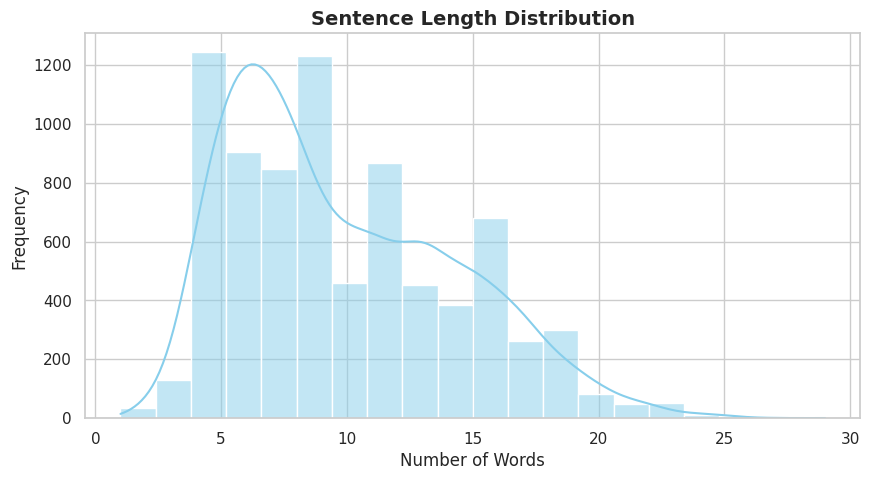

In [46]:
plt.figure(figsize=(10,5))
sns.histplot(dataset['sentence_length'], bins=20, kde=True, color='skyblue')
plt.title("Sentence Length Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

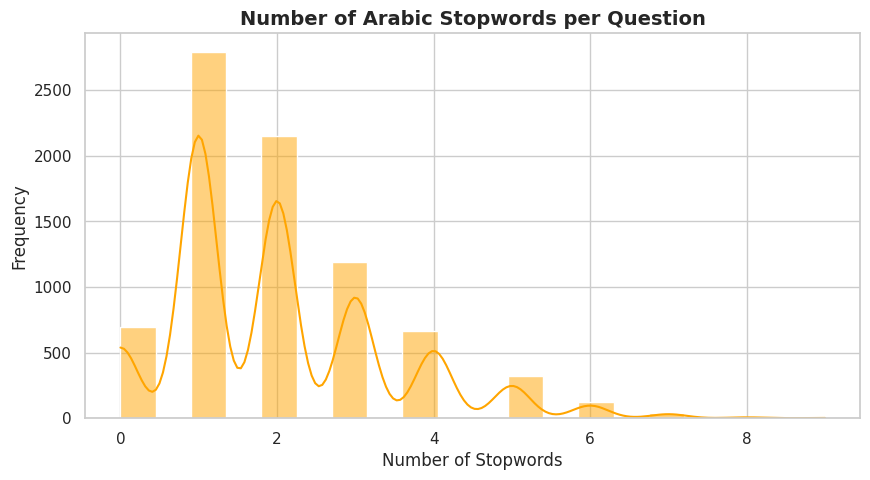

In [47]:
plt.figure(figsize=(10,5))
sns.histplot(dataset['num_arabic_stopwords'], bins=20, kde=True, color='orange')
plt.title("Number of Arabic Stopwords per Question", fontsize=14, fontweight='bold')
plt.xlabel("Number of Stopwords")
plt.ylabel("Frequency")
plt.show()

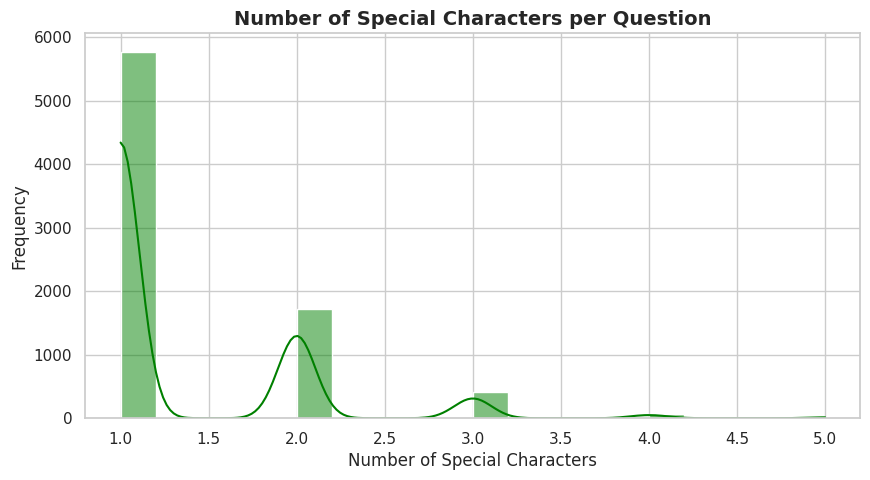

In [48]:
plt.figure(figsize=(10,5))
sns.histplot(dataset['num_special_chars'], bins=20, kde=True, color='green')
plt.title("Number of Special Characters per Question", fontsize=14, fontweight='bold')
plt.xlabel("Number of Special Characters")
plt.ylabel("Frequency")
plt.show()

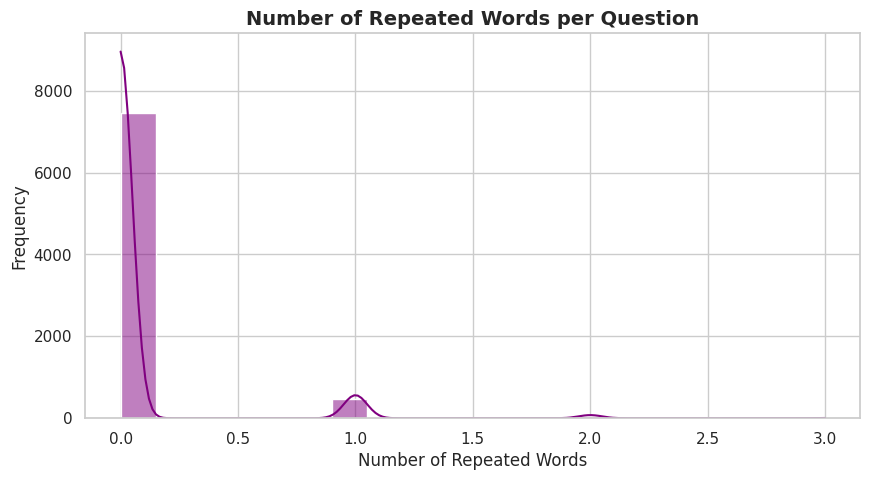

In [49]:
dataset['num_repeated_words'] = dataset['repeated_words'].apply(lambda x: len(x))

plt.figure(figsize=(10,5))
sns.histplot(dataset['num_repeated_words'], bins=20, kde=True, color='purple')
plt.title("Number of Repeated Words per Question", fontsize=14, fontweight='bold')
plt.xlabel("Number of Repeated Words")
plt.ylabel("Frequency")
plt.show()

In [51]:
dataset.to_csv("classfiy_data.csv", index=False)